In [1]:
using Random, Distributions, Plots
function Mean(X) #Calculates sample mean.
    n=length(X)
    return 1/n*sum(X)
end
function Var(X,mu) #Calculate sample variance.
    n=length(X)
    return sum((X-ones(n)*mu).^2)/(n-1)
end
function Covar(X1,X2,mu) #Calculate covariance between X_1 and X_2
    N = length(X1)
    return 1/(N-1)*sum((X1-ones(N)*mu).*(X2-ones(N)*mu))
end

Covar (generic function with 1 method)

Overall Acceptance Probability: 0.5897
Autocorrelation


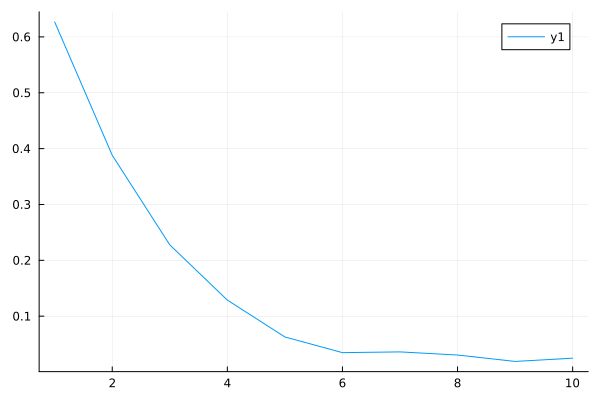

X Samples


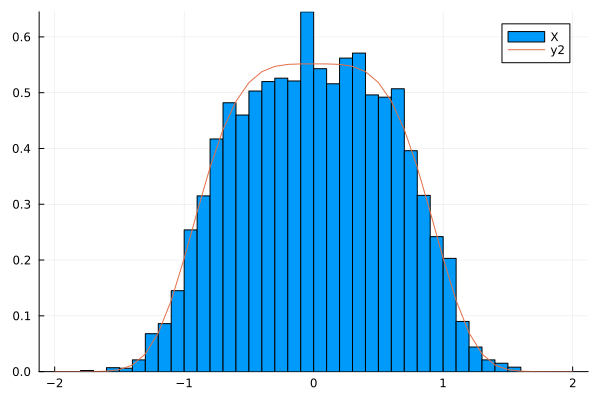

In [2]:
#Lecture 15.1
#We use the Metropolis Hastings Algorithm to sample from a continuous probability distribution.
function Metropolis_Hastings(f,q,x0,N)
    X = ones(N)*x0 #Where we'll store our samples
    U = Uniform(0,1)
    R = 0 #We'll use this to count how many rejections occur
    for i =2:N
        Y = q(X[i-1]) #Proposal.
        alpha = min(f(Y)/f(X[i-1]),1) #Acceptance probability.  Here our q is symmetric, so alpha simplifies.
        u = rand(U)
        if u<=alpha #Accept
            X[i]=Y
        else #Reject
            X[i]=X[i-1]
            R+=1
        end
    end
    return [X,R]
end    

f(x) = exp(-x^4) #The (unnormalized) target pdf we want to sample from.
c = 1.8128 #Approximate normalization constant.  Not needed for MCMC, but we'll use it to compare our results to the true pdf
N = 10000 #Number of samples to generate.
v = 1 #.1, 10
dist = Normal(0,sqrt(v))
q(x) = x+rand(dist) #Proposal distribution
x0 = 0 #It's clear from f this is a good (high probability) starting point, so we won't need a burn in period.
D = Metropolis_Hastings(f,q,x0,N)
X = D[1]
println("Overall Acceptance Probability: ",1-D[2]/N)
L = mean(X)
K = 1:10 #Lags for covariance analysis
R = zeros(length(K)) #Autocorrelation
i=1
for k in K
    X_t = X[1:length(X)-k]
    X_lag = X[1+k:N]
    s1 = sqrt(Var(X_t,L))
    s2 = sqrt(Var(X_lag,L))
    R[i] = Covar(X_t,X_lag,L)/(s1*s2)
    i=i+1
end
println("Autocorrelation")
display(plot(K,R))
println("X Samples")
histogram(X,label="X",normalize=:pdf)
x=-2:.1:2
plot!(x,f.(x)/c)

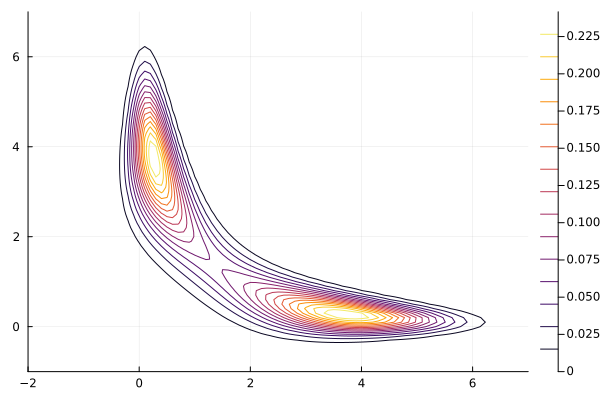

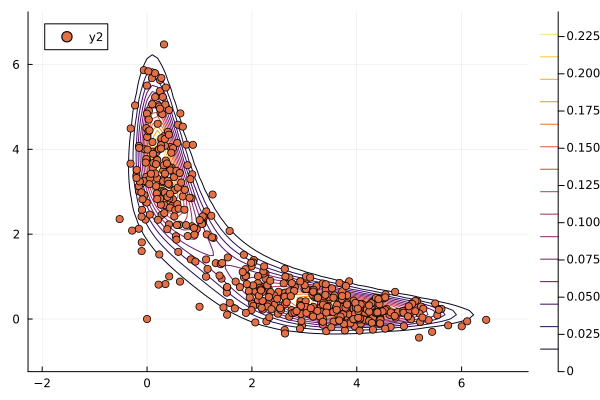

In [3]:
#Lecture 15.2
#We use the Gibbs sampler to generate samples of a bivariate distribution.
c = 1/20216.33587
f(x,y) = c*exp(-.5*(x^2*y^2+x^2+y^2-8*x-8*y))
Z = Normal(0,1)
X_y(y) = rand(Z)/sqrt(1+y^2)+4/(1+y^2) #Conditional distribution
N = 500
X = zeros(N)
Y = zeros(N)
for i=2:N #We'll use (0,0) as the inital value
    X[i]=X_y(Y[i-1])
    Y[i]=X_y(X[i]) #Note we use the X we just generated, rather than the previous X
end
x=-2:.1:7
y=-1:.1:7
z=f.(x',y)
display(contour(x,y,z))
scatter!(X,Y)

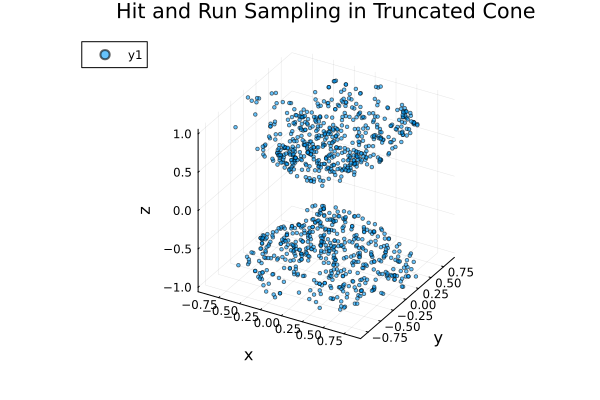

In [11]:
using Distributions, Plots

function Random_Direction()
    # Properly generate uniform random direction on S²
    # Using Box-Muller-like transformation for sphere
    u1, u2 = rand(), rand()
    theta = 2π * u1
    phi = acos(2u2 - 1)  # More uniform than rand()*2π
    return [sin(phi)*cos(theta), sin(phi)*sin(theta), cos(phi)]
end

function Compute_Box_Intersection(x, d)
    T = Float64[]
    for i = 1:length(x)
        if abs(d[i]) > 1e-10  # Numerical stability
            t1 = (-1 - x[i]) / d[i]
            t2 = (1 - x[i]) / d[i]
            append!(T, [t1, t2])
        end
    end
    t_pos = filter(t -> t > 1e-10, T)  # Small positive tolerance
    t_neg = filter(t -> t < -1e-10, T)
    
    return isempty(t_neg) || isempty(t_pos) ? [0.0, 0.0] : [maximum(t_neg), minimum(t_pos)]
end

function Compute_Cone_Intersection(x₀, d)
    # Solve for intersections with cone surface z² = x² + y²
    # Parametric line: p(t) = x₀ + t*d
    # Substituting: (z₀ + t*dz)² = (x₀ + t*dx)² + (y₀ + t*dy)²
    
    a = d[1]^2 + d[2]^2 - d[3]^2
    b = 2*(x₀[1]*d[1] + x₀[2]*d[2] - x₀[3]*d[3])
    c = x₀[1]^2 + x₀[2]^2 - x₀[3]^2
    
    discriminant = b^2 - 4*a*c
    
    if abs(a) < 1e-10  # Linear case
        return abs(b) > 1e-10 ? [-c/b] : Float64[]
    elseif discriminant >= 0
        sqrt_disc = sqrt(discriminant)
        return [(-b - sqrt_disc)/(2*a), (-b + sqrt_disc)/(2*a)]
    else
        return Float64[]
    end
end

function Is_In_Cone(x)
    return x[3]^2 > x[1]^2 + x[2]^2 && -1 < x[3] < 1
end

function Hit_And_Run_Sample(x₀, N)
    X, Y, Z = zeros(N), zeros(N), zeros(N)
    X[1], Y[1], Z[1] = x₀
    
    current_point = copy(x₀)
    
    for i = 2:N
        d = Random_Direction()
        
        # Get intersections with box boundaries
        t_box = Compute_Box_Intersection(current_point, d)
        
        if t_box[1] >= t_box[2]  # No valid interval
            continue
        end
        
        # Sample uniformly on the line segment and accept/reject
        max_attempts = 1000
        accepted = false
        
        for attempt = 1:max_attempts
            t = rand() * (t_box[2] - t_box[1]) + t_box[1]
            candidate = current_point + t * d
            
            if Is_In_Cone(candidate)
                current_point = candidate
                X[i], Y[i], Z[i] = current_point
                accepted = true
                break
            end
        end
        
        if !accepted
            # Keep previous point
            X[i], Y[i], Z[i] = current_point
        end
    end
    
    return X, Y, Z
end

# Main execution
x₀ = [0.0, 0.0, 0.5]  # Starting point inside cone
N = 1000

# Verify starting point is valid
@assert Is_In_Cone(x₀) "Starting point must be inside the cone"

X, Y, Z = Hit_And_Run_Sample(x₀, N)

# Visualization
p = scatter(X, Y, Z, markersize=2, alpha=0.6, 
           title="Hit and Run Sampling in Truncated Cone",
           xlabel="x", ylabel="y", zlabel="z")
display(p)
